# Credit Card Default Prediction
### From probability to credit policy

A card issuer has 30,000 live accounts. Some stop paying each month, and each one
costs roughly three quarters of the outstanding balance. The obvious question is
*who defaults* — but the commercial question is **where to draw the line**, which
is arithmetic about margin and loss, not modelling.

**Data:** UCI #350, 30,000 Taiwanese cardholders, Apr–Sep 2005, outcome measured
in October. 22.12% default rate.

**Result:** XGBoost without resampling — ROC-AUC 0.7808, KS 0.4313, calibrated to
within 0.2% of the realised default rate. At a matched 77.7% approval rate the
model cuts the book's bad rate from 14.2% to 13.2% against a rules-based baseline.

**Three findings worth reading for:** SMOTE degraded the model and was dropped on
evidence; a SHAP dependence plot misread the model because of collinearity I
created; and exposure is U-shaped across the risk spectrum, which moves the
optimal cutoff.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# LightGBM warns on every predict because the pipeline hands it a numpy
# array while it was fitted with feature names. Cosmetic, ~200 lines.
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", None)   # 24 columns; don't let pandas hide any
pd.set_option("display.width", 200)

In [2]:
df = pd.read_csv("data/raw/credit_default.csv")
df.shape

(30000, 24)

## 1 · Exploratory analysis

**Question:** What is in this data, what predicts default, and what is broken?

Run on **raw, uncleaned data** deliberately — cleaning first leaves no record of
what was wrong, and the audit is itself a deliverable.

**Conclusion:** Behaviour dominates demography. September repayment status spans a
12.8% → 69.1% default rate, while sex, education, marital status and age each move
the rate by a few points around the 22.12% average. The data also contradicts its
own codebook in three places, and the money columns are severely right-skewed
(payments at 14.67).

In [3]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_1      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64
 21  PAY_AMT5   3

In [5]:
# The one number the whole project hangs off.
print(df["DEFAULT"].value_counts())
df["DEFAULT"].value_counts(normalize=True)

DEFAULT
0    23364
1     6636
Name: count, dtype: int64


DEFAULT
0    0.7788
1    0.2212
Name: proportion, dtype: float64

In [6]:
# 23 continuous columns matching exactly is a double-load, not coincidence.
df.duplicated().sum()

np.int64(35)

In [7]:
# Validate the data against its own codebook.
# Documented: EDUCATION 1-4, MARRIAGE 1-3. Anything else is undocumented.
for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    print(col)
    print(df[col].value_counts().sort_index())
    print()

SEX
SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64



In [8]:
# Documented: -1 = paid duly, 1..9 = months late. Note -2 and 0 are not in the docs.
df["PAY_1"].value_counts().sort_index()

PAY_1
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

In [9]:
# Resolve the undocumented codes behaviourally: how do those accounts behave?
# -2, -1 and 0 all sit BELOW the 22% average -> three flavours of "current".
df.groupby("PAY_1")["DEFAULT"].agg(["mean", "size"])

,mean,size
PAY_1,,
-2,0.132294,2759
-1,0.167781,5686
0,0.128113,14737
1,0.339479,3688
2,0.691414,2667
3,0.757764,322
4,0.684211,76
5,0.500000,26
6,0.545455,11


In [10]:
for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    print(df.groupby(col)["DEFAULT"].agg(["mean", "size"]), "\n")

         mean   size
SEX                 
1    0.241672  11888
2    0.207763  18112 

               mean   size
EDUCATION                 
0          0.000000     14
1          0.192348  10585
2          0.237349  14030
3          0.251576   4917
4          0.056911    123
5          0.064286    280
6          0.156863     51 

              mean   size
MARRIAGE                 
0         0.092593     54
1         0.234717  13659
2         0.209283  15964
3         0.260062    323 



In [11]:
age_band = pd.cut(df["AGE"], [20, 25, 30, 35, 40, 50, 60, 80])
df.groupby(age_band, observed=True)["DEFAULT"].agg(["mean", "size"])

,mean,size
AGE,,
"(20, 25]",0.266598,3871
"(25, 30]",0.201484,7142
"(30, 35]",0.194272,5796
"(35, 40]",0.216189,4917
"(40, 50]",0.232973,6005
"(50, 60]",0.252379,1997
"(60, 80]",0.268382,272


In [12]:
df[["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]].describe()

,LIMIT_BAL,AGE,BILL_AMT1,PAY_AMT1
count,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,35.485500,51223.330900,5663.580500
std,129747.661567,9.217904,73635.860576,16563.280354
min,10000.000000,21.000000,-165580.000000,0.000000
25%,50000.000000,28.000000,3558.750000,1000.000000
50%,140000.000000,34.000000,22381.500000,2100.000000
75%,240000.000000,41.000000,67091.000000,5006.000000
max,1000000.000000,79.000000,964511.000000,873552.000000


In [13]:
# Skew > 1 is high. Payments at ~15 is extreme -> justifies a power transform.
df[["LIMIT_BAL", "BILL_AMT1", "PAY_AMT1"]].skew()

LIMIT_BAL     0.992867
BILL_AMT1     2.663861
PAY_AMT1     14.668364
dtype: float64

In [14]:
# Negative bills are overpaid accounts carrying a credit balance - real, not an error.
print("min bill:", df["BILL_AMT1"].min())
print("negative bills:", (df["BILL_AMT1"] < 0).sum())
print("over-limit:", (df["BILL_AMT1"] > df["LIMIT_BAL"]).sum())

min bill: -165580
negative bills: 590
over-limit: 2115


In [15]:
# Six snapshots of one slowly-moving balance -> multicollinearity for a linear model.
df[[f"BILL_AMT{i}" for i in range(1, 7)]].corr()

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
BILL_AMT1,1.000000,0.951484,0.892279,0.860272,0.829779,0.802650
BILL_AMT2,0.951484,1.000000,0.928326,0.892482,0.859778,0.831594
BILL_AMT3,0.892279,0.928326,1.000000,0.923969,0.883910,0.853320
BILL_AMT4,0.860272,0.892482,0.923969,1.000000,0.940134,0.900941
BILL_AMT5,0.829779,0.859778,0.883910,0.940134,1.000000,0.946197
BILL_AMT6,0.802650,0.831594,0.853320,0.900941,0.946197,1.000000


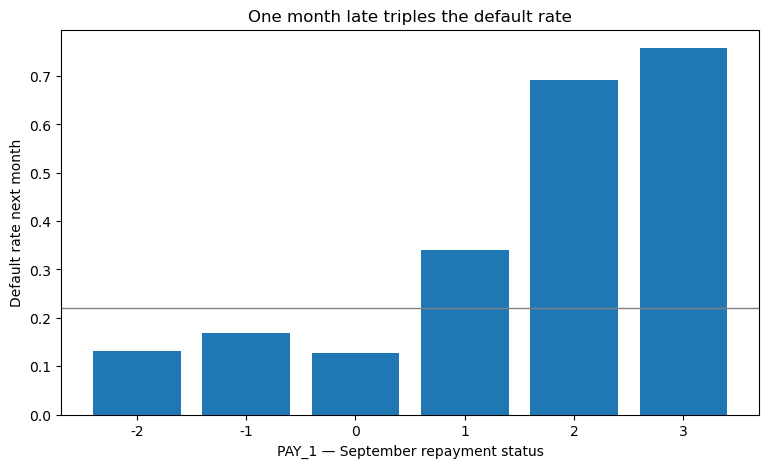

In [16]:
# Headline chart: repayment status vs default rate.
rates = df.groupby("PAY_1")["DEFAULT"].agg(["mean", "size"])
rates = rates[rates["size"] >= 100]          # drop levels too thin to trust

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(rates.index.astype(str), rates["mean"])
ax.axhline(df["DEFAULT"].mean(), color="grey", linewidth=1)
ax.set_xlabel("PAY_1 — September repayment status")
ax.set_ylabel("Default rate next month")
ax.set_title("One month late triples the default rate")
plt.show()

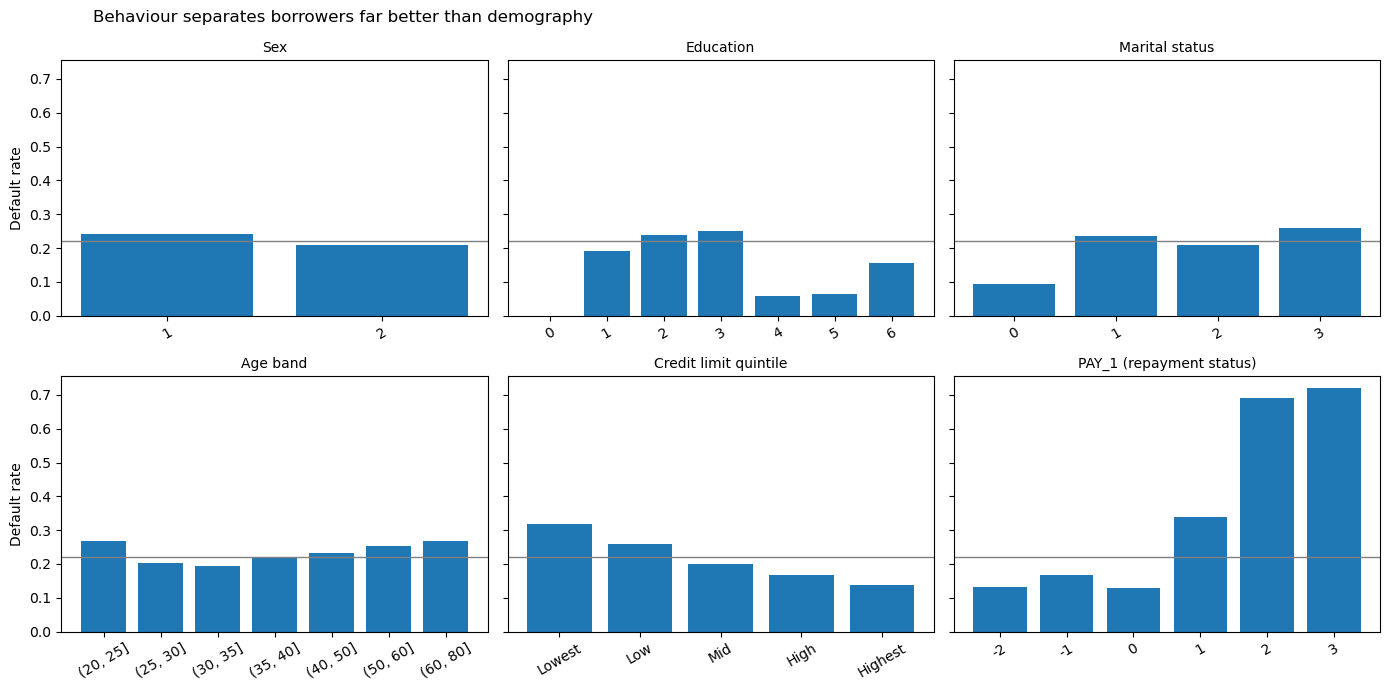

In [17]:
# The argument chart: five segmentations on a SHARED y-axis.
# On independent axes matplotlib auto-zooms each panel and the demographic
# ones look just as dramatic. Shared scale is what makes the point.
limit_band = pd.qcut(df["LIMIT_BAL"], 5, labels=["Lowest", "Low", "Mid", "High", "Highest"])
panels = [
    (df["SEX"], "Sex"),
    (df["EDUCATION"], "Education"),
    (df["MARRIAGE"], "Marital status"),
    (age_band, "Age band"),
    (limit_band, "Credit limit quintile"),
    (df["PAY_1"].clip(upper=3), "PAY_1 (repayment status)"),
]

base = df["DEFAULT"].mean()
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
for ax, (series, title) in zip(axes.ravel(), panels):
    r = df.groupby(series, observed=True)["DEFAULT"].mean()
    ax.bar(r.index.astype(str), r.values)
    ax.axhline(base, color="grey", linewidth=1)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis="x", labelrotation=30)
axes[0, 0].set_ylabel("Default rate")
axes[1, 0].set_ylabel("Default rate")
fig.suptitle("Behaviour separates borrowers far better than demography", x=0.07, ha="left")
plt.tight_layout()
plt.show()

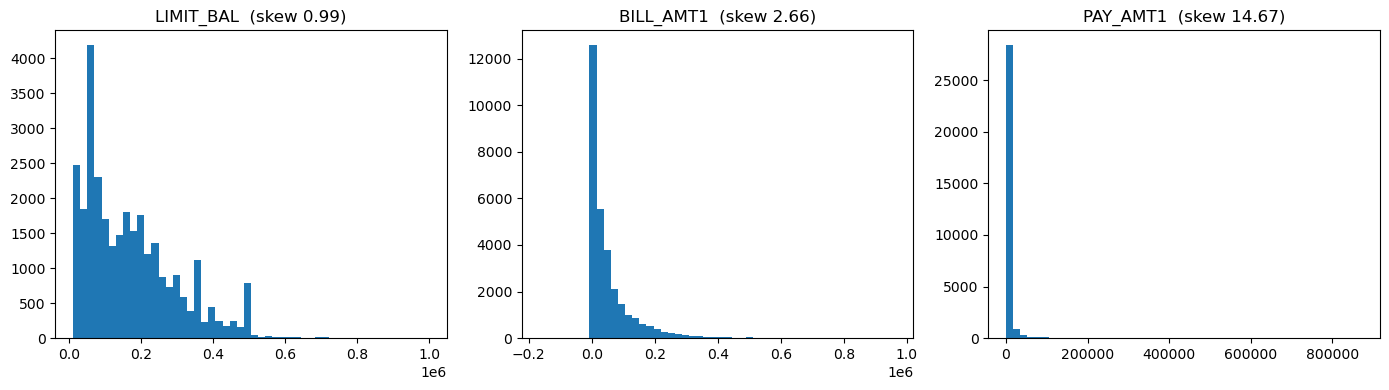

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["LIMIT_BAL", "BILL_AMT1", "PAY_AMT1"]):
    ax.hist(df[col], bins=50)
    ax.set_title(f"{col}  (skew {df[col].skew():.2f})")
plt.tight_layout()
plt.show()

## 2 · Cleaning

**Question:** What actually needs fixing, and what only looks broken?

**Conclusion:** Three fixes — 35 exact duplicate rows dropped (identical across 23
continuous columns is a double-load, not coincidence), and the undocumented
`EDUCATION` {0,5,6} and `MARRIAGE` {0} codes folded into the existing "other"
buckets.

Two things deliberately **kept**: negative bills are overpaid accounts carrying a
credit balance, and over-limit balances are a genuine, risky account state. Both
are real customer conditions carrying real signal.

Nothing that *learns a parameter* happens here — that has to wait for the split.

In [19]:
df_clean = df.drop_duplicates().reset_index(drop=True)

# Undocumented codes fold into the existing "other" bucket rather than becoming
# new levels the model must learn from a handful of examples.
df_clean["EDUCATION"] = df_clean["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df_clean["MARRIAGE"]  = df_clean["MARRIAGE"].replace({0: 3})

print(f"{len(df)} -> {len(df_clean)} rows")
print(df_clean["EDUCATION"].value_counts().sort_index())
print(df_clean["MARRIAGE"].value_counts().sort_index())

30000 -> 29965 rows
EDUCATION
1    10563
2    14019
3     4915
4      468
Name: count, dtype: int64
MARRIAGE
1    13643
2    15945
3      377
Name: count, dtype: int64


## 3 · Train/test split

**Question:** Where is the line that makes every subsequent number trustworthy?

The test for what may happen *before* this point: **does this row's output depend
on any other row?** Dropping duplicates and remapping codes pass. Winsorising,
Box-Cox, scaling and SMOTE all fail — each learns a number from the data.

**Conclusion:** Stratified 80/20, so both halves carry the 22.12% event rate.
From here, `X_test` is not touched until a finished model is evaluated — not to
fit a scaler, not to pick a threshold.

In [20]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=["DEFAULT"])
y = df_clean["DEFAULT"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(X_train.shape, X_test.shape)
print(f"train event rate {y_train.mean():.4f}")
print(f"test  event rate {y_test.mean():.4f}")

(23972, 23) (5993, 23)
train event rate 0.2213
test  event rate 0.2213


## 4 · Feature engineering

**Question:** Six bill columns correlate above 0.9 with each other. How do we
express what an analyst actually reads off a statement?

**Conclusion:** 19 behavioural features — utilisation (scale-free across different
credit limits), repayment ratios, delinquency counts, and trend features capturing
whether an account is deteriorating or recovering.

One timing subtlety that matters: **`PAY_AMT1` is the September payment, which
settles the August bill (`BILL_AMT2`).** Pairing `PAY_AMT{n}` with `BILL_AMT{n}`
compares a payment against a bill it never paid. The correct ratio is
`PAY_AMT{n} / BILL_AMT{n+1}`.

Written as a pure row-wise function applied to both splits — nothing is fitted, so
leakage is structurally impossible rather than merely avoided.

In [21]:
def engineer(data):
    """Row-wise feature engineering. Every output for a row depends only on
    that row, so this is safe to apply before or after the split."""
    d = data.copy()
    bill = [f"BILL_AMT{i}" for i in range(1, 7)]
    pay_stat = [f"PAY_{i}" for i in range(1, 7)]

    # --- utilisation: how full is the line? scale-free across limits ---
    for i, col in enumerate(bill, start=1):
        d[f"UTIL_{i}"] = (d[col] / d["LIMIT_BAL"]).clip(-1, 3)
    util = [f"UTIL_{i}" for i in range(1, 7)]
    d["UTIL_MEAN"] = d[util].mean(axis=1)
    d["UTIL_TREND"] = d["UTIL_1"] - d["UTIL_6"]      # +ve = line filling up

    # --- delinquency summary across the window ---
    d["MONTHS_DELINQUENT"] = d[pay_stat].gt(0).sum(axis=1)
    d["MAX_DELINQUENCY"]   = d[pay_stat].max(axis=1)
    d["MONTHS_PAID_FULL"]  = d[pay_stat].eq(-1).sum(axis=1)
    d["DELINQ_TREND"]      = d["PAY_1"] - d["PAY_6"]

    # --- repayment ratio ---
    # PAY_AMT{i} is paid in month i and settles the PREVIOUS month's bill,
    # BILL_AMT{i+1}. Only i = 1..5 have a previous bill inside the window.
    for i in range(1, 6):
        prev_bill = d[f"BILL_AMT{i+1}"]
        ratio = d[f"PAY_AMT{i}"] / prev_bill.where(prev_bill > 0)
        d[f"PAY_RATIO_{i}"] = ratio.fillna(1.0).clip(0, 2)

    ratios = [f"PAY_RATIO_{i}" for i in range(1, 6)]
    d["PAY_RATIO_MEAN"] = d[ratios].mean(axis=1)
    d["PAY_RATIO_MIN"]  = d[ratios].min(axis=1)

    return d

In [22]:
X_train_fe = engineer(X_train)
X_test_fe  = engineer(X_test)
print(X_train_fe.shape, X_test_fe.shape)

(23972, 42) (5993, 42)


## 5 · Preprocessing pipeline

**Question:** How do we apply transforms that *learn* from data without letting
test information leak backwards?

**Conclusion:** Everything with a fitted parameter lives in a `ColumnTransformer`
that fits on training folds only. Three column groups, three treatments: nominal
one-hot encoded, ordinal scaled, skewed continuous winsorised → Box-Cox → scaled.

Box-Cox needs strictly positive input, but this data has bills as low as −339,603
and thousands of zero payments — so a custom transformer learns a per-column shift
of `1 − min` on training data.

Skew on `PAY_AMT2` falls from **31.99 to 0.19**. Tree models skip this path
entirely: gradient boosting splits on rank order, so a monotone transform provably
cannot change a single split it chooses.

In [23]:
NOMINAL = ["SEX", "EDUCATION", "MARRIAGE"]

# Already small signed integers on a meaningful scale - scaling is enough.
ORDINAL = [f"PAY_{i}" for i in range(1, 7)] + [
    "MONTHS_DELINQUENT", "MAX_DELINQUENCY", "MONTHS_PAID_FULL", "DELINQ_TREND",
]

# Heavy-tailed continuous: winsorise, then Box-Cox, then standardise.
SKEWED = (
    ["LIMIT_BAL", "AGE"]
    + [f"BILL_AMT{i}" for i in range(1, 7)]
    + [f"PAY_AMT{i}" for i in range(1, 7)]
    + [f"UTIL_{i}" for i in range(1, 7)]
    + ["UTIL_MEAN", "UTIL_TREND"]
    + [f"PAY_RATIO_{i}" for i in range(1, 6)]
    + ["PAY_RATIO_MEAN", "PAY_RATIO_MIN"]
)

print(len(NOMINAL) + len(ORDINAL) + len(SKEWED), "of", X_train_fe.shape[1])

42 of 42


In [24]:
# Box-Cox needs strictly positive input. These do not qualify.
X_train_fe[SKEWED].min().sort_values().head(8)

BILL_AMT6    -339603.0000
BILL_AMT1    -165580.0000
BILL_AMT3    -157264.0000
BILL_AMT4     -81334.0000
BILL_AMT2     -69777.0000
BILL_AMT5     -61372.0000
UTIL_TREND        -1.8273
UTIL_2            -1.0000
dtype: float64

In [25]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import PowerTransformer


class Winsorizer(BaseEstimator, TransformerMixin):
    """Clip each column to train-set percentile bounds.

    Outlier *treatment*, not removal: a client with a 900k bill is a real
    client we still have to score, so we pull the value in rather than
    drop the row."""

    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lower_ = np.nanpercentile(X, self.lower * 100, axis=0)
        self.upper_ = np.nanpercentile(X, self.upper * 100, axis=0)
        return self

    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.lower_, self.upper_)

    def get_feature_names_out(self, input_features=None):
        # Neither transformer adds, drops, or reorders columns.
        return np.asarray(input_features, dtype=object)


class ShiftedBoxCox(BaseEstimator, TransformerMixin):
    """Box-Cox with a per-column shift learned on the training set, so
    columns containing zero or negative values can still use it."""

    EPS = 1e-6

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        col_min = np.nanmin(X, axis=0)
        # Only shift where needed; already-positive columns are left alone.
        self.shift_ = np.where(col_min <= 0, 1.0 - col_min, 0.0)
        self.power_ = PowerTransformer(method="box-cox", standardize=False)
        self.power_.fit(np.maximum(X + self.shift_, self.EPS))
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return self.power_.transform(np.maximum(X + self.shift_, self.EPS))

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def build_preprocessor(box_cox=True):
    """Column-wise preprocessing, fitted on the training fold only.

    box_cox=False gives tree models a cheaper path: gradient boosting splits
    on rank order, so a monotone transform cannot change a single split it
    chooses. One-hot encoding still applies."""
    skewed_steps = [("winsorize", Winsorizer())]
    if box_cox:
        skewed_steps += [("boxcox", ShiftedBoxCox()), ("scale", StandardScaler())]

    return ColumnTransformer(
        transformers=[
            ("nominal", OneHotEncoder(drop="first", handle_unknown="ignore",
                                      sparse_output=False), NOMINAL),
            ("ordinal", StandardScaler() if box_cox else "passthrough", ORDINAL),
            ("skewed", Pipeline(skewed_steps), SKEWED),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


pre = build_preprocessor(box_cox=True)
Xt_train = pre.fit_transform(X_train_fe)      # fit on TRAIN
Xt_test  = pre.transform(X_test_fe)           # transform only
print(Xt_train.shape, Xt_test.shape)

(23972, 45) (5993, 45)


In [27]:
# Prove the transform did something.
before = X_train_fe[SKEWED].skew().abs()
after = pd.DataFrame(
    pre.named_transformers_["skewed"].transform(X_train_fe[SKEWED]),
    columns=SKEWED,
).skew().abs()

pd.DataFrame({"before": before, "after": after}).sort_values("before", ascending=False).head(10)

,before,after
PAY_AMT2,31.992701,0.192283
PAY_AMT3,18.539164,0.206075
PAY_AMT1,15.618873,0.208591
PAY_AMT4,11.740485,0.207227
PAY_AMT5,10.854087,0.222500
PAY_AMT6,10.697865,0.206660
BILL_AMT3,3.182606,0.139933
BILL_AMT5,2.891269,0.131974
BILL_AMT6,2.872336,0.109967
BILL_AMT4,2.855295,0.135720


## 6 · Model training

**Question:** Which model family reaches the ceiling of this data, and where is
that ceiling?

Five families through one harness, each in an `imblearn` pipeline
(preprocess → SMOTE → classifier) so every learned parameter refits per CV fold.

**Conclusion:** XGBoost leads at 0.7882 CV AUC, but all five land within 0.023 AUC
of each other. **That band is the information ceiling of six months of statement
history — not a tuning shortfall.** The neural network finishes last, which is the
expected result for tabular data with strong monotone features, not a failure.

In [28]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(5, shuffle=True, random_state=42)

# The preprocessor lives INSIDE the pipeline so it refits on each fold.
baseline = ImbPipeline([
    ("pre", build_preprocessor(box_cox=True)),
    ("clf", LogisticRegression(max_iter=3000, random_state=42)),
])

scores = cross_val_score(baseline, X_train_fe, y_train, cv=cv, scoring="roc_auc")
print(f"no SMOTE : {scores.mean():.4f} +/- {scores.std():.4f}")

no SMOTE : 0.7657 +/- 0.0102


In [29]:
from imblearn.over_sampling import SMOTE

# imblearn's Pipeline applies SMOTE on fit and skips it on predict, so each
# fold resamples only its training portion and the held-out fold keeps 22%.
with_smote = ImbPipeline([
    ("pre", build_preprocessor(box_cox=True)),
    ("smote", SMOTE(random_state=42)),
    ("clf", LogisticRegression(max_iter=3000, random_state=42)),
])

scores_s = cross_val_score(with_smote, X_train_fe, y_train, cv=cv, scoring="roc_auc")
print(f"with SMOTE: {scores_s.mean():.4f} +/- {scores_s.std():.4f}")

with SMOTE: 0.7666 +/- 0.0097


### Feature selection — RFECV

**Question:** How many of these features actually earn their place?

Run with `class_weight="balanced"` rather than SMOTE — selecting features against
synthetic minority points would tune the feature set to the sampler rather than
to the problem.

**Conclusion:** RFECV kept **43 of 45** features, and the entire sweep from 5 to 45
features spans just **0.0204 AUC**. Check the y-axis range before reading the shape
of that curve: it reports an optimum, but that optimum is the argmax of a plateau,
not a cliff.

The honest takeaway is the opposite of the usual one — the extra features are not
hurting, and feature count is simply not the lever on this problem. A deployment
wanting a smaller model could cut far more aggressively for a loss in the third
decimal place.

In [30]:
from sklearn.feature_selection import RFECV

feature_names = list(pre.get_feature_names_out())

selector = RFECV(
    LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    step=2, cv=cv, scoring="roc_auc", min_features_to_select=5, n_jobs=-1,
)
selector.fit(Xt_train, y_train)

scores_rfe = selector.cv_results_["mean_test_score"]
print(f"kept {selector.n_features_} of {Xt_train.shape[1]}")
print(f"best CV AUC {scores_rfe.max():.4f}")
print(f"spread across the whole sweep: {scores_rfe.max() - scores_rfe.min():.4f}")

kept 43 of 45
best CV AUC 0.7684
spread across the whole sweep: 0.0204


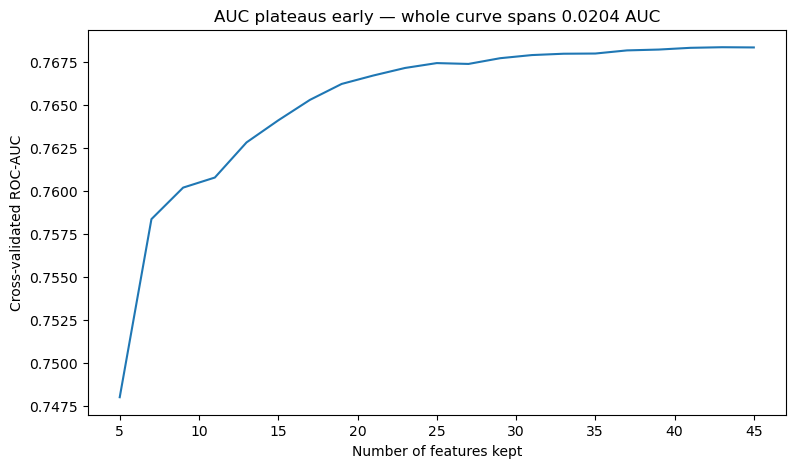

In [31]:
n_feats = list(range(selector.min_features_to_select,
                     selector.min_features_to_select + len(scores_rfe) * selector.step,
                     selector.step))[:len(scores_rfe)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_feats, scores_rfe)
ax.set_xlabel("Number of features kept")
ax.set_ylabel("Cross-validated ROC-AUC")
ax.set_title(f"AUC plateaus early — whole curve spans {scores_rfe.max()-scores_rfe.min():.4f} AUC")
plt.show()

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


def make_pipe(clf, box_cox, smote=True):
    steps = [("pre", build_preprocessor(box_cox=box_cox))]
    if smote:
        steps.append(("smote", SMOTE(random_state=42)))
    steps.append(("clf", clf))
    return ImbPipeline(steps)


# Estimators stay single-threaded: the search already uses n_jobs=-1, and
# letting both layers grab every core oversubscribes the CPU.
SPECS = {
    "Logistic Regression": dict(
        pipe=make_pipe(LogisticRegression(max_iter=3000, random_state=42), box_cox=True),
        params={"clf__C": np.logspace(-3, 2, 20), "clf__penalty": ["l1", "l2"],
                "clf__solver": ["liblinear", "saga"]},
        n_iter=15),

    "Random Forest": dict(
        pipe=make_pipe(RandomForestClassifier(random_state=42, n_jobs=1), box_cox=False),
        params={"clf__n_estimators": [300, 500], "clf__max_depth": [6, 8, 12, 16],
                "clf__min_samples_leaf": [5, 20, 50],
                "clf__max_features": ["sqrt", 0.3]},
        n_iter=10),

    "XGBoost": dict(
        pipe=make_pipe(XGBClassifier(tree_method="hist", eval_metric="logloss",
                                     random_state=42, n_jobs=1), box_cox=False),
        params={"clf__n_estimators": [300, 500], "clf__max_depth": [3, 4, 5, 6],
                "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
                "clf__subsample": [0.7, 0.85, 1.0],
                "clf__colsample_bytree": [0.6, 0.8, 1.0],
                "clf__min_child_weight": [1, 5, 20]},
        n_iter=20),

    "LightGBM": dict(
        pipe=make_pipe(LGBMClassifier(random_state=42, n_jobs=1, verbose=-1), box_cox=False),
        params={"clf__n_estimators": [300, 500], "clf__num_leaves": [15, 31, 63],
                "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
                "clf__min_child_samples": [10, 30, 60],
                "clf__colsample_bytree": [0.6, 0.8, 1.0]},
        n_iter=20),
}

In [33]:
import time

fitted, cv_results = {}, {}

for name, spec in SPECS.items():
    t0 = time.time()
    search = RandomizedSearchCV(spec["pipe"], spec["params"], n_iter=spec["n_iter"],
                                scoring="roc_auc", cv=cv, n_jobs=-1,
                                random_state=42, refit=True)
    search.fit(X_train_fe, y_train)
    fitted[name] = search.best_estimator_
    cv_results[name] = search.best_score_
    print(f"{name:22} CV AUC {search.best_score_:.4f}  ({time.time()-t0:.0f}s)")
    print(f"  {search.best_params_}\n")

Logistic Regression    CV AUC 0.7674  (126s)
  {'clf__solver': 'liblinear', 'clf__penalty': 'l2', 'clf__C': np.float64(0.011288378916846888)}



Random Forest          CV AUC 0.7854  (454s)
  {'clf__n_estimators': 500, 'clf__min_samples_leaf': 5, 'clf__max_features': 0.3, 'clf__max_depth': 8}



XGBoost                CV AUC 0.7882  (80s)
  {'clf__subsample': 0.7, 'clf__n_estimators': 300, 'clf__min_child_weight': 5, 'clf__max_depth': 4, 'clf__learning_rate': 0.03, 'clf__colsample_bytree': 0.6}



LightGBM               CV AUC 0.7880  (83s)
  {'clf__num_leaves': 15, 'clf__n_estimators': 300, 'clf__min_child_samples': 10, 'clf__learning_rate': 0.03, 'clf__colsample_bytree': 0.6}



In [34]:
from tensorflow import keras
from tensorflow.keras import layers

keras.utils.set_random_seed(42)

# Preprocess + resample manually: Keras needs its own validation split, and it
# has to come from the resampled training data.
pre_nn = build_preprocessor(box_cox=True)
Xt_nn = pre_nn.fit_transform(X_train_fe)
Xr, yr = SMOTE(random_state=42).fit_resample(Xt_nn, y_train)

# Deliberately small. 24k rows and ~45 features is not a deep learning problem;
# anything wider memorises the SMOTE neighbourhoods and diverges in a few epochs.
model = keras.Sequential([
    layers.Input(shape=(Xr.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy",
              metrics=[keras.metrics.AUC(name="auc")])

history = model.fit(
    Xr, yr,
    validation_split=0.15, epochs=100, batch_size=256, verbose=0,
    callbacks=[
        # restore_best_weights matters: without it you keep the weights from
        # 12 epochs past your best.
        keras.callbacks.EarlyStopping(monitor="val_auc", mode="max",
                                      patience=12, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                          patience=6, min_lr=1e-5),
    ],
)
print(f"stopped after {len(history.history['loss'])} epochs")

stopped after 13 epochs


## 7 · Evaluation — and the finding AUC cannot see

**Question:** How do these models perform on data they have never seen, and is
ROC-AUC telling us everything?

**Conclusion — this is the most important section in the notebook.** ROC-AUC reads
only the *ordering* of predictions, never their absolute values. That blind spot
hides a real defect.

Every SMOTE-trained model overstates risk, by an amount that scales with how
directly it encodes its training prior — logistic regression predicts 1.97× the
true rate, XGBoost 1.11×. Models with an explicit intercept inherit the artificial
50/50 prior; regularised boosters shrink back toward the data.

The ablation settles it: **no-SMOTE wins on every metric — AUC, PR-AUC, Brier, F1,
precision, and the recall SMOTE exists to buy.** Mean predicted risk 0.2208 against
an actual 0.2213.

At a 22% event rate SMOTE is unnecessary — every class has thousands of examples
and boosting already handles a skewed prior through its loss. **The final model
uses no resampling.**

In [35]:
probas = {name: est.predict_proba(X_test_fe)[:, 1] for name, est in fitted.items()}
probas["Neural Network"] = model.predict(pre_nn.transform(X_test_fe), verbose=0).ravel()
print(list(probas))

['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'Neural Network']


In [36]:
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             f1_score, precision_score, recall_score, confusion_matrix)


def evaluate(y_true, p):
    """Threshold-free metrics, plus metrics at the F1-optimal cut.

    0.5 is a convention inherited from balanced problems, not a decision.
    Choosing the cutoff on business cost is Section 9."""
    grid = np.linspace(0.05, 0.95, 181)
    f1s = [f1_score(y_true, (p >= t).astype(int), zero_division=0) for t in grid]
    best_t = grid[int(np.argmax(f1s))]
    pred = (p >= best_t).astype(int)
    return {
        "roc_auc":   roc_auc_score(y_true, p),
        "gini":      2 * roc_auc_score(y_true, p) - 1,
        "pr_auc":    average_precision_score(y_true, p),
        "brier":     brier_score_loss(y_true, p),
        "best_thr":  best_t,
        "f1":        f1_score(y_true, pred, zero_division=0),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall":    recall_score(y_true, pred, zero_division=0),
        "mean_p":    p.mean(),
    }


results = pd.DataFrame({n: evaluate(y_test, p) for n, p in probas.items()}).T
results.sort_values("roc_auc", ascending=False).round(4)

,roc_auc,gini,pr_auc,brier,best_thr,f1,precision,recall,mean_p
XGBoost,0.7771,0.5543,0.5580,0.1368,0.305,0.5373,0.5010,0.5792,0.2501
LightGBM,0.7766,0.5531,0.5576,0.1364,0.320,0.5328,0.5182,0.5483,0.2440
Random Forest,0.7741,0.5482,0.5484,0.1424,0.365,0.5321,0.5030,0.5649,0.2931
Neural Network,0.7588,0.5177,0.5228,0.1679,0.495,0.5276,0.5358,0.5196,0.3846
Logistic Regression,0.7578,0.5156,0.5110,0.1914,0.560,0.5177,0.4880,0.5513,0.4359


In [37]:
# Compare mean_p above against the truth. Every SMOTE model overstates risk.
print(f"actual default rate: {y_test.mean():.4f}")

actual default rate: 0.2213


In [38]:
# Ablation: same algorithm, same hyperparameters, SMOTE the only difference.
best_xgb_params = {k.replace("clf__", ""): v
                   for k, v in fitted["XGBoost"].named_steps["clf"].get_params().items()
                   if k in ("n_estimators", "max_depth", "learning_rate",
                            "subsample", "colsample_bytree", "min_child_weight")}

no_smote = make_pipe(
    XGBClassifier(tree_method="hist", eval_metric="logloss",
                  random_state=42, n_jobs=-1, **best_xgb_params),
    box_cox=False, smote=False,
).fit(X_train_fe, y_train)

probas["XGBoost (no SMOTE)"] = no_smote.predict_proba(X_test_fe)[:, 1]

pd.DataFrame({
    "XGBoost + SMOTE":  evaluate(y_test, probas["XGBoost"]),
    "XGBoost no SMOTE": evaluate(y_test, probas["XGBoost (no SMOTE)"]),
}).T.round(4)

,roc_auc,gini,pr_auc,brier,best_thr,f1,precision,recall,mean_p
XGBoost + SMOTE,0.7771,0.5543,0.5580,0.1368,0.305,0.5373,0.5010,0.5792,0.2501
XGBoost no SMOTE,0.7808,0.5616,0.5664,0.1345,0.270,0.5445,0.5068,0.5882,0.2208


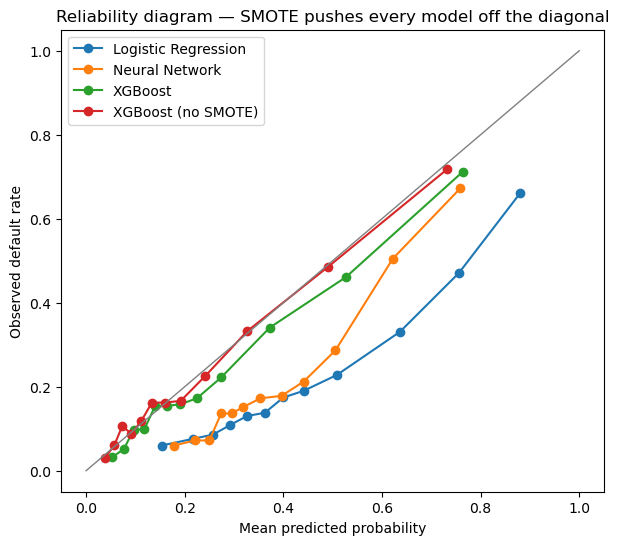

In [39]:
from sklearn.calibration import calibration_curve

# A perfectly calibrated model sits on the diagonal.
fig, ax = plt.subplots(figsize=(7, 6))
for name in ["Logistic Regression", "Neural Network", "XGBoost", "XGBoost (no SMOTE)"]:
    frac, mean_pred = calibration_curve(y_test, probas[name], n_bins=12, strategy="quantile")
    ax.plot(mean_pred, frac, marker="o", label=name)
ax.plot([0, 1], [0, 1], color="grey", linewidth=1)
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed default rate")
ax.set_title("Reliability diagram — SMOTE pushes every model off the diagonal")
ax.legend()
plt.show()

In [40]:
# KS: maximum separation between the cumulative distributions of goods and bads.
# Credit teams quote it as routinely as Gini.
from scipy.stats import ks_2samp

p = probas["XGBoost (no SMOTE)"]
y_arr = y_test.values

ks_exact = ks_2samp(p[y_arr == 1], p[y_arr == 0]).statistic
print(f"KS statistic: {ks_exact:.4f}  ({ks_exact*100:.1f})")

KS statistic: 0.4313  (43.1)


In [41]:
t = pd.DataFrame({"p": p, "y": y_arr})
t["band"] = pd.qcut(t["p"], 10, labels=False, duplicates="drop")

ks_tbl = t.groupby("band").agg(n=("y", "size"), bads=("y", "sum"))
ks_tbl["goods"] = ks_tbl["n"] - ks_tbl["bads"]
ks_tbl = ks_tbl.iloc[::-1]                      # riskiest band first

ks_tbl["cum_bad_%"]  = ks_tbl["bads"].cumsum()  / ks_tbl["bads"].sum()
ks_tbl["cum_good_%"] = ks_tbl["goods"].cumsum() / ks_tbl["goods"].sum()
ks_tbl["KS"] = (ks_tbl["cum_bad_%"] - ks_tbl["cum_good_%"]).abs()
ks_tbl["decile"] = [f"D{i}" for i in range(10, 0, -1)]

print(f"KS = {ks_tbl['KS'].max():.4f} at {ks_tbl.loc[ks_tbl['KS'].idxmax(), 'decile']}")
ks_tbl.round(4)

KS = 0.4253 at D8


,n,bads,goods,cum_bad_%,cum_good_%,KS,decile
band,,,,,,,
9,600,421,179,0.3175,0.0384,0.2791,D10
8,599,250,349,0.5060,0.1131,0.3929,D9
7,599,166,433,0.6312,0.2059,0.4253,D8
6,599,106,493,0.7112,0.3115,0.3996,D7
5,599,101,498,0.7873,0.4183,0.3691,D6
4,600,101,499,0.8635,0.5252,0.3383,D5
3,599,58,541,0.9072,0.6411,0.2661,D4
2,599,54,545,0.9480,0.7579,0.1901,D3
1,599,48,551,0.9842,0.8759,0.1082,D2


## 8 · Interpretability

**Question:** What drives the model's decisions, and can we explain a single
customer's outcome?

Run on the un-resampled model — explaining a SMOTE-trained model would attribute
risk partly to synthetic customers who never existed.

**Conclusion, and a trap I walked into.** `PAY_1`'s dependence plot appears to show
the model ignoring a first missed payment: levels −2, −1, 0 *and* 1 all sit near
−0.2, with the jump only at 2. That contradicts the EDA, where one month late took
the default rate from 12.8% to 33.9%.

Decomposing the attribution resolves it. Total model output moves **+1.435**
log-odds from current to one month late, and **+1.458** from one to two — the two
steps are priced almost identically. The first step simply isn't attributed to
`PAY_1`; the engineered delinquency counts carry it, because they are collinear
with `PAY_1` by construction.

**A single dependence plot is not a statement about model behaviour when the
feature is collinear with others.** You have to sum the group.

LIME also surfaced `EDUCATION_4` behaving as a risk-*raising* factor for every
customer — the "other" bucket defaults at 7.05% vs 22% average, so the model reads
data provenance rather than borrower behaviour. Recommended for removal.

In [42]:
import shap

# TreeExplainer needs the raw booster and already-transformed data;
# it cannot take a pipeline.
Xt_test_nm = no_smote.named_steps["pre"].transform(X_test_fe)
names = list(no_smote.named_steps["pre"].get_feature_names_out())
sample = Xt_test_nm[:2000]           # the beeswarm saturates well before 2000

explainer = shap.TreeExplainer(no_smote.named_steps["clf"])
sv = np.asarray(explainer.shap_values(sample))
if sv.ndim == 3:
    sv = sv[:, :, 1]
print(sv.shape)

(2000, 45)


C:\Users\Asus\AppData\Local\Temp\ipykernel_24268\259353690.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, sample, feature_names=names, max_display=20)


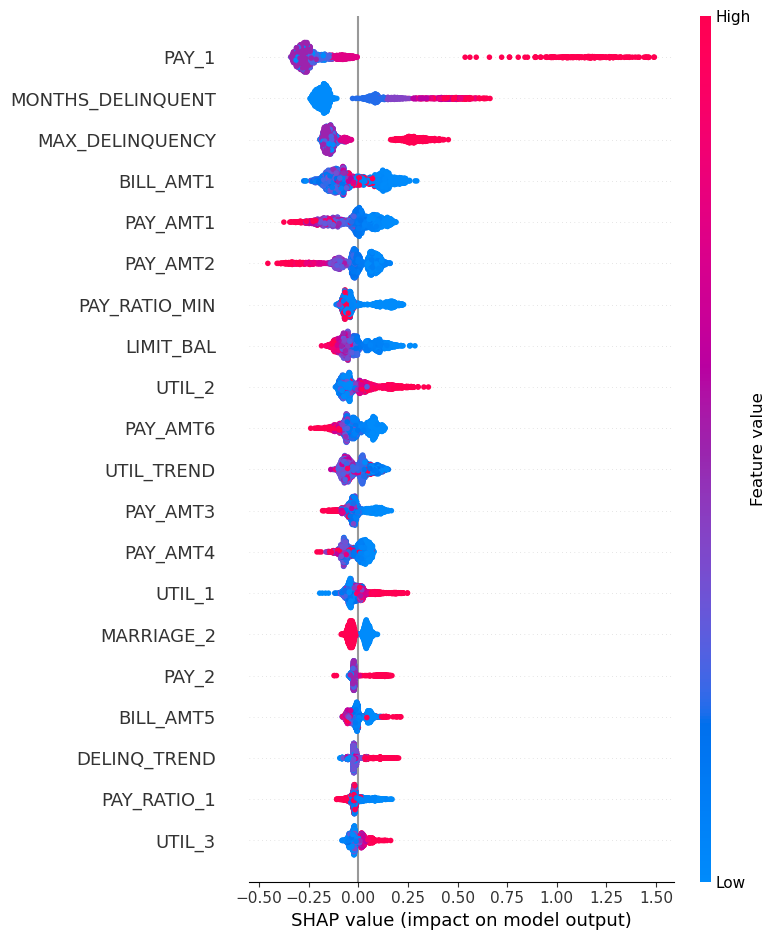

In [43]:
shap.summary_plot(sv, sample, feature_names=names, max_display=20)

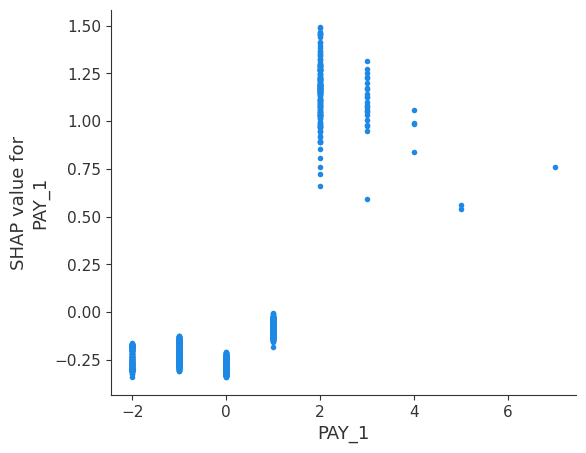

In [44]:
# Read alone, this says the model shrugs at a first missed payment. It doesn't.
shap.dependence_plot("PAY_1", sv, sample, feature_names=names, interaction_index=None)

In [45]:
# Decompose: PAY_1 alone vs the whole collinear delinquency group vs the total.
j = names.index("PAY_1")
group = ([f"PAY_{i}" for i in range(1, 7)]
         + ["MONTHS_DELINQUENT", "MAX_DELINQUENCY", "DELINQ_TREND"])
gidx = [names.index(g) for g in group if g in names]
pay1 = sample[:, j]

rows = []
for lvl in sorted(set(pay1.tolist())):
    mask = pay1 == lvl
    if mask.sum() < 50:
        continue
    rows.append({
        "PAY_1": int(lvl),
        "n": int(mask.sum()),
        "PAY_1 alone": sv[mask, j].mean(),
        "delinquency group": sv[mask][:, gidx].sum(axis=1).mean(),
        "model total": sv[mask].sum(axis=1).mean(),
    })
pd.DataFrame(rows).round(3)

,PAY_1,n,PAY_1 alone,delinquency group,model total
0,-2,176,-0.242,-0.626,-0.782
1,-1,382,-0.224,-0.429,-0.593
2,0,993,-0.280,-0.578,-0.855
3,1,245,-0.082,0.337,0.580
4,2,173,1.160,1.932,2.038


In [46]:
from lime.lime_tabular import LimeTabularExplainer

# SHAP says where risk sits across the book. LIME writes the sentence that goes
# in one customer's decline letter.
Xt_train_nm = no_smote.named_steps["pre"].transform(X_train_fe)
clf = no_smote.named_steps["clf"]
p_test = probas["XGBoost (no SMOTE)"]

lime_exp = LimeTabularExplainer(
    Xt_train_nm, feature_names=names, class_names=["Repay", "Default"],
    mode="classification", discretize_continuous=True, random_state=42,
)

order = np.argsort(p_test)
for label, idx in [("Highest risk", order[-1]),
                   ("Borderline", order[len(order) // 2]),
                   ("Lowest risk", order[0])]:
    e = lime_exp.explain_instance(Xt_test_nm[idx], clf.predict_proba,
                                  num_features=6, num_samples=3000)
    actual = "defaulted" if y_test.iloc[idx] else "repaid"
    print(f"\n{label} — model risk {p_test[idx]:.1%}, actually {actual}")
    for feat, w in e.as_list():
        print(f"   {w:+.4f}  {feat}")


Highest risk — model risk 87.6%, actually defaulted
   +0.0949  PAY_1 > 0.00
   +0.0744  EDUCATION_4 <= 0.00
   +0.0716  MAX_DELINQUENCY > 2.00
   +0.0636  MONTHS_DELINQUENT > 1.00
   +0.0304  PAY_RATIO_MIN <= 0.00
   +0.0282  BILL_AMT1 <= 3580.00



Borderline — model risk 14.7%, actually repaid
   +0.0715  EDUCATION_4 <= 0.00
   -0.0460  MONTHS_DELINQUENT <= 0.00
   -0.0373  -1.00 < PAY_1 <= 0.00
   +0.0295  UTIL_2 > 0.81
   +0.0222  LIMIT_BAL <= 50000.00
   -0.0206  22587.00 < BILL_AMT1 <= 67724.00



Lowest risk — model risk 1.5%, actually repaid
   +0.0807  EDUCATION_4 <= 0.00
   -0.0498  MONTHS_DELINQUENT <= 0.00
   -0.0357  -1.00 < PAY_1 <= 0.00
   -0.0280  PAY_AMT2 > 5000.00
   -0.0256  PAY_AMT1 > 5009.00
   -0.0213  LIMIT_BAL > 240000.00


In [47]:
# LIME flagged EDUCATION_4 as risk-raising for everyone. Verify why:
# the "other" bucket defaults far below average, so the model reads provenance.
df_clean.groupby("EDUCATION")["DEFAULT"].agg(["mean", "size"])

,mean,size
EDUCATION,,
1,0.192370,10563
2,0.237392,14019
3,0.251679,4915
4,0.070513,468


### Fair lending — what do the protected attributes actually buy?

`SEX`, `EDUCATION` and `MARRIAGE` are protected characteristics under ECOA /
Regulation B and comparable RBI fair-practice expectations, so a deployable model
cannot use them. LIME also showed `EDUCATION_4` acting as a proxy for data
provenance rather than borrower behaviour — the "other" bucket defaults at 7.05%
against a 22% average, and there is no credit story for why an unrecorded
education code should make a borrower safe.

The EDA predicted removal would be nearly free. **Measure it rather than assume it.**

**Conclusion:** removing all three costs **0.0015 AUC** (0.7808 → 0.7793), with
Brier unchanged to four decimals and PR-AUC essentially flat. The compliant model
is the same model — the behavioural features were carrying the signal all along.

In [48]:
# Does dropping the protected attributes actually cost anything?

def build_preprocessor_v(nominal, box_cox=False):
    """Same as build_preprocessor but with a configurable nominal column list."""
    trs = []
    if nominal:
        trs.append(("nominal", OneHotEncoder(drop="first", handle_unknown="ignore",
                                             sparse_output=False), nominal))
    skewed_steps = [("winsorize", Winsorizer())]
    if box_cox:
        skewed_steps += [("boxcox", ShiftedBoxCox()), ("scale", StandardScaler())]
    trs += [("ordinal", StandardScaler() if box_cox else "passthrough", ORDINAL),
            ("skewed", Pipeline(skewed_steps), SKEWED)]
    return ColumnTransformer(trs, remainder="drop", verbose_feature_names_out=False)


VARIANTS = {
    "Baseline (SEX + EDUCATION + MARRIAGE)": ["SEX", "EDUCATION", "MARRIAGE"],
    "Drop EDUCATION only":                   ["SEX", "MARRIAGE"],
    "Drop all three protected attributes":   [],
}

rows = []
for label, nominal in VARIANTS.items():
    v = Pipeline([
        ("pre", build_preprocessor_v(nominal, box_cox=False)),
        ("clf", XGBClassifier(tree_method="hist", eval_metric="logloss",
                              random_state=42, n_jobs=-1, **best_xgb_params)),
    ]).fit(X_train_fe, y_train)
    pv = v.predict_proba(X_test_fe)[:, 1]
    m = evaluate(y_test, pv)
    rows.append({"variant": label,
                 "n_features": v.named_steps["pre"].transform(X_test_fe).shape[1],
                 "roc_auc": m["roc_auc"], "pr_auc": m["pr_auc"], "brier": m["brier"]})

fair = pd.DataFrame(rows)
fair["auc_delta"] = fair["roc_auc"] - fair.loc[0, "roc_auc"]
fair.round(4)

,variant,n_features,roc_auc,pr_auc,brier,auc_delta
0,Baseline (SEX + EDUCATION + MARRIAGE),45,0.7808,0.5664,0.1345,0.0000
1,Drop EDUCATION only,42,0.7798,0.5666,0.1345,-0.0009
2,Drop all three protected attributes,39,0.7793,0.5643,0.1346,-0.0015


## 9 · From probability to policy

**Question:** A probability is not a decision. Where should the cutoff sit, and
what does each choice cost?

Every candidate cutoff applied to the holdout and priced against **realised**
outcomes: loss = P(default) × exposure × LGD, revenue = margin × exposure. A
backtest of a policy, not a forecast.

**Conclusion:** Approving everyone loses NT$6.94M — an 18% margin cannot carry a
22% default rate at 75% LGD. The profit optimum sits at 0.1775, stricter than the
analytic break-even of 0.1935.

That gap is informative: **exposure is U-shaped across the risk spectrum.** The
safest decile averages NT$65.6k (transactors who clear their balance), the middle
drops to NT$22.9k, and the riskiest climbs back to NT$59.9k — maxed-out revolvers
defaulting at 70%. A policy tuned on account counts alone would under-price exactly
the segment doing the damage.

**The fair benchmark** is not "approve everyone" — it is the rule a bank runs
without a model. Held to the same 77.7% approval rate, the model books a 13.2% bad
rate against the rule's 14.2%, worth NT$701k on 6,000 accounts.

In [49]:
LGD    = 0.75   # loss given default — unsecured card recovery ~25%
MARGIN = 0.18   # net annual margin on a carried balance, after funding and opex

# Exposure at default: balance actually outstanding. Credit limit would overstate
# it (most accounts never draw the full line); negatives are overpaid accounts.
exposure = X_test_fe["BILL_AMT1"].clip(lower=0).values

# One more approval is worth taking while (1-p)*MARGIN*E > p*LGD*E.
# E cancels, leaving p < MARGIN / (MARGIN + LGD).
BREAK_EVEN = MARGIN / (MARGIN + LGD)
print(f"break-even cutoff: {BREAK_EVEN:.4f}")
print(f"total exposure: {exposure.sum():,.0f}")

break-even cutoff: 0.1935
total exposure: 307,743,964


In [50]:
def simulate(cutoffs):
    rows = []
    for t in cutoffs:
        approved = p < t
        n_appr = int(approved.sum())
        bad_appr = int((approved & (y_arr == 1)).sum())
        loss = (exposure * approved * (y_arr == 1) * LGD).sum()
        revenue = (exposure * approved * (y_arr == 0) * MARGIN).sum()
        rows.append({
            "cutoff": t,
            "approval_rate": n_appr / len(y_arr),
            "n_approved": n_appr,
            "bad_rate_approved": bad_appr / n_appr if n_appr else 0.0,
            "capture_rate": 1 - bad_appr / y_arr.sum(),
            "loss": loss,
            "revenue": revenue,
            "profit": revenue - loss,
        })
    return pd.DataFrame(rows)


sim = simulate(np.linspace(0.02, 1.0, 393))
best = sim.loc[sim["profit"].idxmax()]

print(f"profit-optimal cutoff : {best['cutoff']:.4f}")
print(f"approval rate         : {best['approval_rate']:.1%}")
print(f"bad rate on approved  : {best['bad_rate_approved']:.1%}")
print(f"defaults captured     : {best['capture_rate']:.0%}")
print(f"net profit            : {best['profit']:,.0f}")
print(f"approve everyone      : {sim.iloc[-1]['profit']:,.0f}")

profit-optimal cutoff : 0.1775
approval rate         : 59.1%
bad rate on approved  : 10.5%
defaults captured     : 72%
net profit            : 17,344,984
approve everyone      : -6,942,420


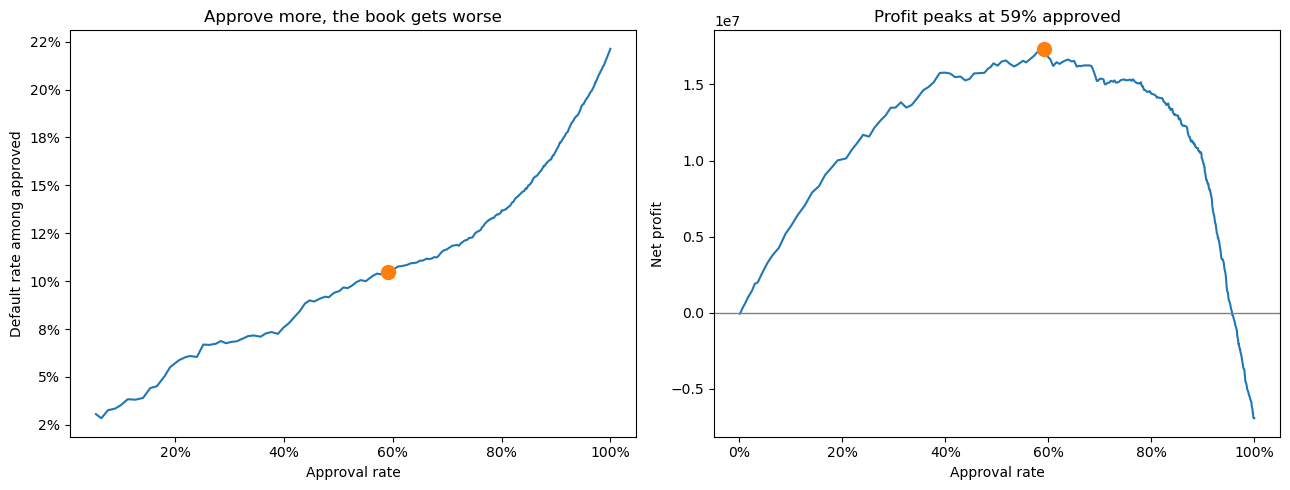

In [51]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

readable = sim[sim["n_approved"] >= 300]     # tiny approved sets are noise
ax1.plot(readable["approval_rate"], readable["bad_rate_approved"])
ax1.plot(best["approval_rate"], best["bad_rate_approved"], "o", markersize=10)
ax1.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax1.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax1.set_xlabel("Approval rate")
ax1.set_ylabel("Default rate among approved")
ax1.set_title("Approve more, the book gets worse")

ax2.plot(sim["approval_rate"], sim["profit"])
ax2.plot(best["approval_rate"], best["profit"], "o", markersize=10)
ax2.axhline(0, color="grey", linewidth=1)
ax2.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax2.set_xlabel("Approval rate")
ax2.set_ylabel("Net profit")
ax2.set_title(f"Profit peaks at {best['approval_rate']:.0%} approved")
plt.tight_layout()
plt.show()

In [52]:
# The algebra assumed exposure cancels - true only if every account is the same
# size. Replace every balance with the portfolio mean and see where it lands.
flat = np.full_like(exposure, exposure.mean(), dtype=float)
cuts = np.linspace(0.02, 1.0, 393)
flat_profit = [(flat * (p < t) * (y_arr == 0) * MARGIN).sum()
               - (flat * (p < t) * (y_arr == 1) * LGD).sum() for t in cuts]

print(f"optimum, real exposure : {best['cutoff']:.4f}")
print(f"optimum, flat exposure : {cuts[int(np.argmax(flat_profit))]:.4f}")
print(f"analytic break-even    : {BREAK_EVEN:.4f}")

optimum, real exposure : 0.1775
optimum, flat exposure : 0.2200
analytic break-even    : 0.1935


In [53]:
# Exposure is U-shaped: large at the safe end (transactors who clear their
# balance) AND at the risky end (maxed-out revolvers who cannot).
d = pd.DataFrame({"p": p, "exposure": exposure, "y": y_arr})
d["decile"] = pd.qcut(d["p"], 10, labels=False)
d.groupby("decile").agg(
    mean_exposure=("exposure", "mean"),
    bad_rate=("y", "mean"),
    n=("y", "size"),
).round(3)

,mean_exposure,bad_rate,n
decile,,,
0,65573.063,0.035,600
1,66728.467,0.080,599
2,56942.114,0.090,599
3,65194.528,0.097,599
4,51324.135,0.168,600
5,50190.344,0.169,599
6,42838.591,0.177,599
7,22933.564,0.277,599
8,31845.063,0.417,599


In [54]:
# The only fair benchmark: the rule a bank runs WITHOUT a model,
# held to the same approval rate.
rule_approved = (X_test_fe["PAY_1"] < 1).values          # decline anyone 1+ month late
n = int(rule_approved.sum())
bad = int((rule_approved & (y_arr == 1)).sum())
rule_profit = ((exposure * rule_approved * (y_arr == 0) * MARGIN).sum()
               - (exposure * rule_approved * (y_arr == 1) * LGD).sum())

rule = {"approval_rate": n / len(y_arr), "bad_rate": bad / n,
        "capture": 1 - bad / y_arr.sum(), "profit": rule_profit}

matched = sim.iloc[(sim["approval_rate"] - rule["approval_rate"]).abs().idxmin()]

print(f"rule  : approval {rule['approval_rate']:.1%}  bad {rule['bad_rate']:.1%}  "
      f"capture {rule['capture']:.0%}  profit {rule['profit']:,.0f}")
print(f"model : approval {matched['approval_rate']:.1%}  bad {matched['bad_rate_approved']:.1%}  "
      f"capture {matched['capture_rate']:.0%}  profit {matched['profit']:,.0f}")

rule  : approval 77.7%  bad 14.2%  capture 50%  profit 14,359,531
model : approval 77.7%  bad 13.2%  capture 54%  profit 15,060,866


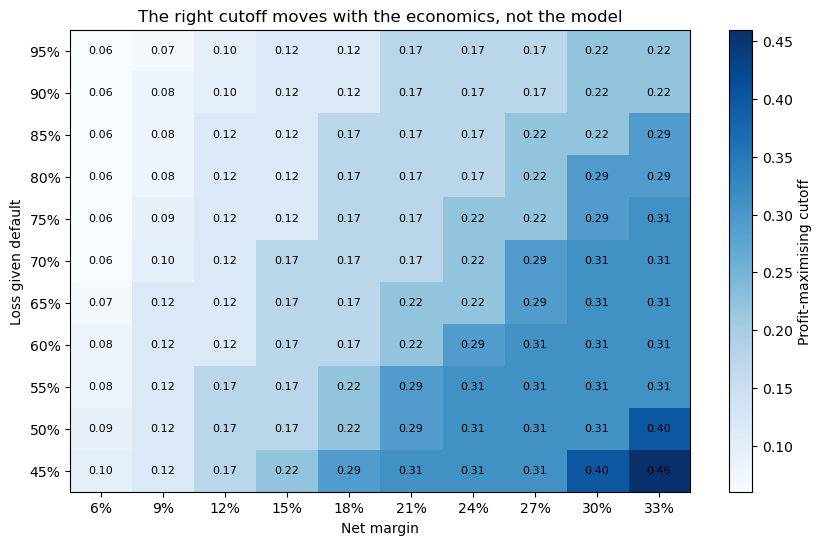

cutoff ranges 0.06 to 0.46 (7.7x) across plausible assumptions


In [55]:
# The cutoff is a function of the economics, not of the model.
margins = np.round(np.arange(0.06, 0.33, 0.03), 3)
lgds = np.round(np.arange(0.45, 0.96, 0.05), 3)
cuts = np.linspace(0.02, 1.0, 197)

grid = np.zeros((len(lgds), len(margins)))
for i, lgd in enumerate(lgds):
    for j, m in enumerate(margins):
        profits = [(exposure * (p < t) * (y_arr == 0) * m).sum()
                   - (exposure * (p < t) * (y_arr == 1) * lgd).sum() for t in cuts]
        grid[i, j] = cuts[int(np.argmax(profits))]

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(grid, aspect="auto", origin="lower", cmap="Blues",
               vmin=grid.min(), vmax=grid.max())
ax.set_xticks(range(len(margins)), [f"{m:.0%}" for m in margins])
ax.set_yticks(range(len(lgds)), [f"{l:.0%}" for l in lgds])
ax.set_xlabel("Net margin"); ax.set_ylabel("Loss given default")
for i in range(len(lgds)):
    for j in range(len(margins)):
        ax.text(j, i, f"{grid[i,j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, label="Profit-maximising cutoff")
ax.set_title("The right cutoff moves with the economics, not the model")
plt.show()

print(f"cutoff ranges {grid.min():.2f} to {grid.max():.2f} "
      f"({grid.max()/grid.min():.1f}x) across plausible assumptions")

### Export for the policy simulator

The Streamlit app (`app.py`) reads a pre-scored test set rather than loading the
model, so it starts instantly and carries no xgboost/sklearn dependency at
runtime. Everything it needs is the score, the realised outcome, the exposure,
and `PAY_1` for the rules-based benchmark.

Run `streamlit run app.py` after this cell.

In [56]:
from pathlib import Path

out = pd.DataFrame({
    "p":         np.round(p, 6),          # predicted default probability
    "y":         y_arr,                   # realised outcome
    "exposure":  exposure,                # balance at risk, floored at zero
    "pay_1":     X_test_fe["PAY_1"].values,       # for the rules benchmark
    "limit_bal": X_test_fe["LIMIT_BAL"].values,
    "util_1":    np.round(X_test_fe["UTIL_1"].values, 4),
})

path = Path("data/processed/scored_test.csv")
path.parent.mkdir(parents=True, exist_ok=True)
out.to_csv(path, index=False)

print(f"wrote {path}  ({len(out):,} rows)")
print(f"mean predicted {out.p.mean():.4f} vs actual {out.y.mean():.4f}")
out.head()

wrote data\processed\scored_test.csv  (5,993 rows)
mean predicted 0.2208 vs actual 0.2213


,p,y,exposure,pay_1,limit_bal,util_1
0,0.107979,0,39177,0,50000,0.7835
1,0.080988,0,168376,0,240000,0.7016
2,0.112740,0,6090,0,90000,0.0677
3,0.190776,0,30631,0,50000,0.6126
4,0.021397,0,44734,0,230000,0.1945


## Conclusions and limitations

**What this project establishes**

1. Behavioural features dominate demographics — repayment status spans 13%–69%,
   demographics move a few points around 22%.
2. There is a ~0.78 AUC ceiling that five model families all reach.
3. SMOTE degraded this model. Measured, not assumed.
4. SHAP attribution splits across collinear features — read the group, not the panel.
5. Exposure is U-shaped across risk, which shifts the profit-maximising cutoff.

**Limitations**

- **No out-of-time validation.** The split is stratified random; the data covers one
  six-month window. A production model needs a forward-looking holdout to catch drift.
- **One market, one period.** Taiwan, 2005. The method transfers; the numbers do not.
- **Economic assumptions are illustrative.** LGD 75% and margin 18% were chosen, not
  derived — which is why the sensitivity grid is the deliverable rather than any
  single cutoff. The optimum ranges 0.06–0.46 across plausible values.
- **`SEX`, `EDUCATION` and `MARRIAGE` are protected characteristics** and would not
  survive a fair-lending review. The EDA suggests removing them costs almost nothing.
- **Exposure is proxied** by the most recent bill; real EAD modelling accounts for
  undrawn commitment, since distressed borrowers draw down before defaulting.